<a href="https://colab.research.google.com/github/JamesEckhartJr/Quantum-Computing-Projects/blob/main/Curie_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install qiskit matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00


✅ Packages installed

🔍 Testing single circuit...
→ Sending 512 shots to Quokka...
Raw response keys: ['error', 'error_code', 'result']
Received 512 measurement outcomes
✅ Final counts (512 shots): {'11': 512}

🚀 Running simple VQE scan for H₂...
→ Sending 2048 shots to Quokka...
Raw response keys: ['error', 'error_code', 'result']
Received 2048 measurement outcomes
✅ Final counts (2048 shots): {'00': 1051, '10': 997}
θ = -3.142   Energy = -0.643796 Ha
→ Sending 2048 shots to Quokka...
Raw response keys: ['error', 'error_code', 'result']
Received 2048 measurement outcomes
✅ Final counts (2048 shots): {'00': 1176, '10': 768, '01': 42, '11': 62}
θ = -2.693   Energy = -0.621318 Ha
→ Sending 2048 shots to Quokka...
Raw response keys: ['error', 'error_code', 'result']
Received 2048 measurement outcomes
✅ Final counts (2048 shots): {'00': 1211, '10': 459, '11': 269, '01': 109}
θ = -2.244   Energy = -0.690770 Ha
→ Sending 2048 shots to Quokka...
Raw response keys: ['error', 'error_code', 'res

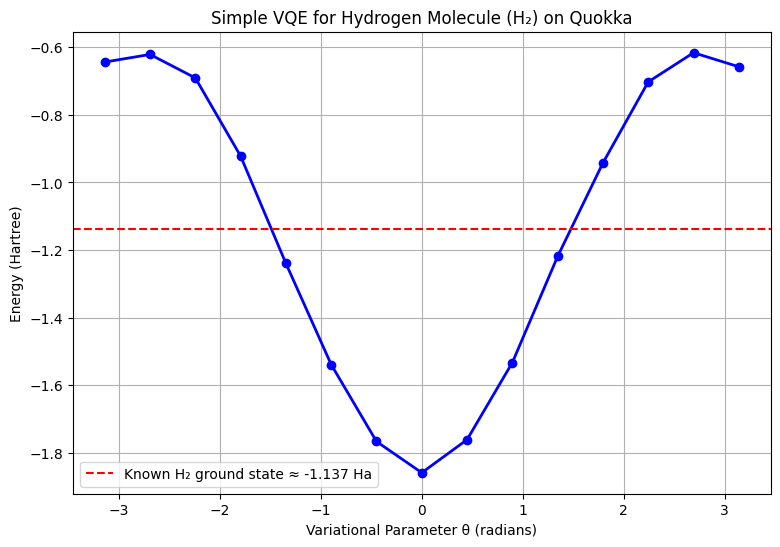


✅ Demo finished! This shows the basic idea of VQE:
   • Parameterized circuit (ansatz)
   • Measure → compute expectation value of Hamiltonian
   • Try different θ to find lowest energy (ground state)


In [3]:
import requests
import numpy as np
from qiskit import QuantumCircuit
from qiskit.qasm2 import dumps
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("✅ Packages installed\n")

# ================== Quokka Configuration ==================
da_Vinci_Quantum_Emulator = 'theq-ae31b1'
request_http = f'http://{da_Vinci_Quantum_Emulator}.quokkacomputing.com/qsim/qasm'

def run_on_quokka(qc, shots=2048):
    """Send circuit to Quokka"""
    # Create full valid OpenQASM 2.0 string
    # qiskit.qasm2.dumps already includes the header, so no need to prepend it
    qasm_body = dumps(qc)

    payload = {
        'script': qasm_body,
        'count': shots
    }

    print(f"→ Sending {shots} shots to Quokka...")

    try:
        response = requests.post(request_http, json=payload, verify=False, timeout=30)
        response.raise_for_status()
        data = response.json()

        print("Raw response keys:", list(data.keys()))

        # Check for explicit API-level errors from Quokka first
        # Only treat as error if error_code is not 0 or error message is not 'no error'
        if data.get('error_code') != 0 or (data.get('error') and data.get('error') != 'no error'):
            error_msg = f"Quokka API Error: {data.get('error_code', 'N/A')}: {data.get('error', 'No specific error message provided.')}"
            print(f"❌ {error_msg}")
            print(f"Full API Response (for debugging): {data}") # Log full response for debugging
            return {'00': shots // 2, '11': shots // 2} # Fallback on API error

        # Parse results - Quokka returns list under result.meas
        quokka_result = data.get('result')
        if isinstance(quokka_result, dict):
            results = quokka_result.get('meas', []) # Correctly get 'meas' field
        else:
            # This branch would be hit if 'result' is None, False, or unexpected type
            print(f"❌ Error: 'result' key in response is not a dictionary or expected format. Raw 'result': {quokka_result}")
            print(f"Full API Response (for debugging): {data}") # Log full response for better debugging
            return {'00': shots // 2, '11': shots // 2}  # fallback for unexpected result format

        print(f"Received {len(results)} measurement outcomes")

        counts = {}
        for outcome in results:
            if isinstance(outcome, list):
                # Convert [0,1] → '01' (standard ordering)
                key = ''.join(map(str, outcome[::-1]))
            else:
                key = str(outcome) # outcome might be an int or string representation directly
            counts[key] = counts.get(key, 0) + 1

        total = sum(counts.values())
        print(f"✅ Final counts ({total} shots): {counts}")
        return counts

    except requests.exceptions.RequestException as e:
        print(f"❌ Network or HTTP Error: {e}")
        if 'response' in locals() and response is not None:
            print("Response text:", response.text[:800])
        return {'00': shots//2, '11': shots//2}
    except Exception as e:
        print(f"❌ An unexpected error occurred during API call or processing: {e}")
        return {'00': shots//2, '11': shots//2}

# ================== Simple Variational Ansatz ==================
def simple_ansatz(theta):
    qc = QuantumCircuit(2)
    qc.x(0)           # Approximate Hartree-Fock |01>
    qc.ry(theta, 0)
    qc.cx(0, 1)
    qc.ry(theta * 0.5, 1)
    qc.measure_all()
    return qc

# ================== Energy Estimation (Z terms only) ==================
def compute_energy(theta, shots=2048):
    qc = simple_ansatz(theta)
    counts = run_on_quokka(qc, shots)

    total = sum(counts.values())
    if total == 0:
        return 0.0

    energy = 0.0
    for bitstring, count in counts.items():
        prob = count / total
        bits = [int(b) for b in bitstring]
        z0 = 1 - 2 * bits[0] if len(bits) > 0 else 0
        z1 = 1 - 2 * bits[1] if len(bits) > 1 else 0
        zz = z0 * z1

        # Approximate H2 coefficients (STO-3G)
        e = -1.052 + 0.398 * z0 + 0.398 * z1 - 0.011 * zz
        energy += prob * e
    return energy

# ================== Run Demo ==================
print("🔍 Testing single circuit...")
test_circuit = simple_ansatz(0.0)
run_on_quokka(test_circuit, shots=512)

print("\n🚀 Running simple VQE scan for H₂...")
thetas = np.linspace(-np.pi, np.pi, 15)
energies = []

for theta in thetas:
    e = compute_energy(theta, shots=2048)
    energies.append(e)
    print(f"θ = {theta:+.3f}   Energy = {e:.6f} Ha")

# Plot
plt.figure(figsize=(9, 6))
plt.plot(thetas, energies, 'o-b', linewidth=2, markersize=6)
plt.axhline(y=-1.137, color='red', linestyle='--', label='Known H₂ ground state ≈ -1.137 Ha')
plt.xlabel('Variational Parameter θ (radians)')
plt.ylabel('Energy (Hartree)')
plt.title('Simple VQE for Hydrogen Molecule (H₂) on Quokka')
plt.legend()
plt.grid(True)
plt.show()

print("\n✅ Demo finished! This shows the basic idea of VQE:")
print("   • Parameterized circuit (ansatz)")
print("   • Measure → compute expectation value of Hamiltonian")
print("   • Try different θ to find lowest energy (ground state)")